## Fase 1: Estado del Arte y Contexto Industrial
En el ámbito del **Mantenimiento Predictivo (Condition Monitoring)**, la monitorización de vibraciones es el estándar de la industria, respaldado por normativas internacionales como la **ISO 10816**. 

Físicamente, cuando un componente mecánico (como un rodamiento) sufre un desgaste o fisura, no genera vibraciones aleatorias. Produce impactos repetitivos a frecuencias cinemáticas muy específicas. Además, anomalías macroestructurales como la **desalineación** o el **desequilibrio** generan anomalías de energía enormes en los primeros armónicos de la frecuencia de giro del motor.

**Objetivo de este Notebook:**
Antes de realizar la extracción masiva de características, es fundamental auditar la calidad de los datos crudos y aplicar técnicas de acondicionamiento de señal, ya que las señales industriales del mundo real sufren de ruido y desviaciones continuas (DC offset). 

En este documento analizaremos una muestra sana y una defectuosa (Desalineación Severa), pasando por **6 etapas críticas**:
1. **Control de Calidad y Etiquetado:** Verificación de valores nulos y mapeo de sensores.
2. **Análisis en el Dominio Temporal:** Comparativa de la forma de onda y densidad de energía.
3. **Preprocesado matemático:** Aplicación de *Detrend* y *Ventanado de Hamming* para limpieza de señal.
4. **Análisis en el Dominio Frecuencial:** Aplicación de la Transformada Rápida de Fourier (FFT) y búsqueda de armónicos.
5. **Análisis Multicanal:** Evaluación de la sensibilidad por eje físico y comparativa acústica (micrófono) vs. vibración (acelerómetro).
6. **Análisis Tiempo-Frecuencia y Separabilidad:** Espectrogramas (STFT) y validación de métricas de negocio (RMS, Curtosis).

In [1]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal.windows import hamming
from scipy.stats import kurtosis, skew

## 1. Configuración, Carga y Control de Calidad
A continuación, definimos las rutas, mapeamos los 8 canales de sensores y creamos una función para extraer la etiqueta de avería directamente del nombre de las carpetas.

In [2]:
# Configuración de gráficas
def setup_graph(title='', x_label='', y_label='', fig_size=(12, 5)):
    fig, ax = plt.subplots(figsize=fig_size)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True, alpha=0.3)
    return fig, ax

In [3]:
# Configuración inicial y Rutas
CARPETA_BASE = '../../Datos/Originales/03_Validacion/bearing_fault_detection'
COLS = ['tachometer', 'acc_under_axial','acc_under_radiale','acc_under_tangencial', 
        'acc_over_axial','acc_over_radiale','acc_over_tangencial','microphone']
FS = 51200 # Frecuencia de muestreo (51.2 kHz)

In [4]:
path_normal = os.path.join(CARPETA_BASE, 'normal/18.432.csv') 
path_fallo = os.path.join(CARPETA_BASE, 'horizontal-misalignment/1.0mm/18.8416.csv')

In [5]:
# Función de carga unificada
def cargar_y_etiquetar(path):
    df = pd.read_csv(path, header=None)
    if len(df.columns) == len(COLS):
        df.columns = COLS
        
    parts = os.path.relpath(os.path.dirname(path), CARPETA_BASE).split(os.sep)
    if parts[0] == 'normal':
        df['clase'], df['subclase'] = 'normal', '0'
    elif len(parts) > 2:
        df['clase'], df['subclase'] = f'{parts[0]}_{parts[1]}', parts[2]
    else:
        df['clase'], df['subclase'] = parts[0], parts[1]
    return df

df_n = cargar_y_etiquetar(path_normal)
df_f = cargar_y_etiquetar(path_fallo)

canal = 'acc_under_axial'
sig_n_raw = df_n[canal].values
sig_f_raw = df_f[canal].values

print("--- 1. CONTROL DE CALIDAD Y ETIQUETADO ---")
print(f"Motor Sano  [{df_n['clase'].iloc[0]}] -> Muestras: {len(sig_n_raw)} | Nulos: {np.isnan(sig_n_raw).sum()}")
print(f"Motor Fallo [{df_f['clase'].iloc[0]} - {df_f['subclase'].iloc[0]}] -> Muestras: {len(sig_f_raw)} | Nulos: {np.isnan(sig_f_raw).sum()}")

--- 1. CONTROL DE CALIDAD Y ETIQUETADO ---
Motor Sano  [normal] -> Muestras: 250000 | Nulos: 0
Motor Fallo [horizontal-misalignment - 1.0mm] -> Muestras: 250000 | Nulos: 0


## 2. Análisis en el Dominio del Tiempo
Comparamos la forma de onda cruda y la distribución de densidades (KDE). Un ensanchamiento en la curva de densidad es un indicador temprano de que la máquina está vibrando con mayor intensidad.

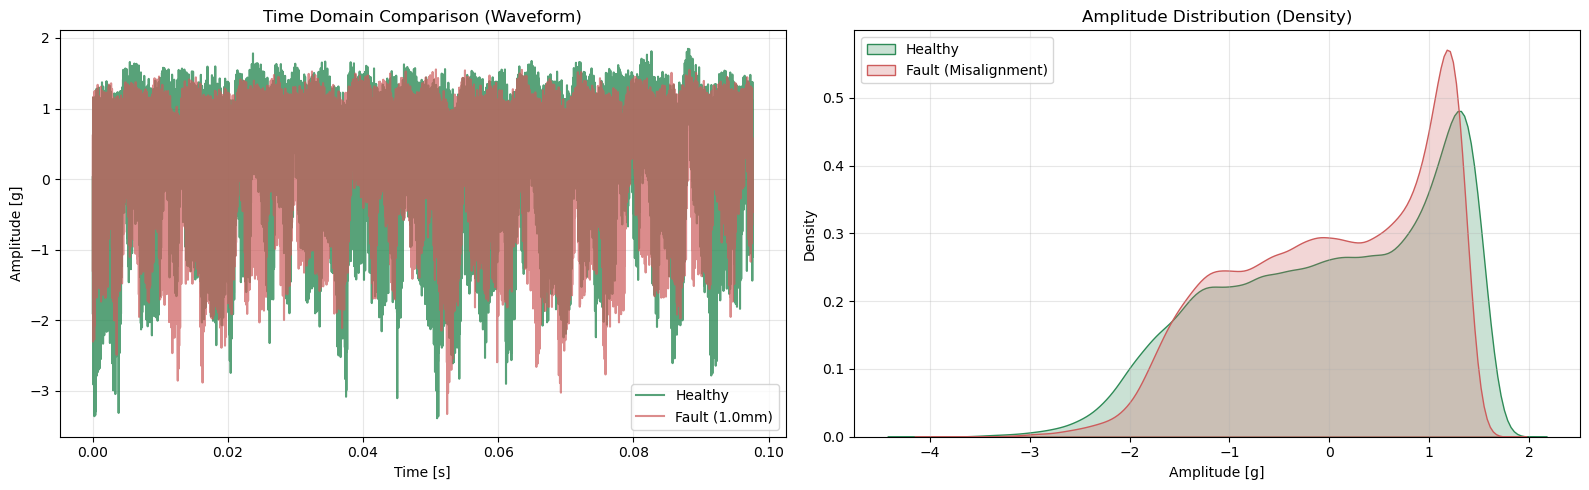

In [6]:
# --- 2. TIME DOMAIN ANALYSIS ---
time = np.linspace(0, len(sig_n_raw)/FS, len(sig_n_raw), endpoint=False)
zoom = 5000 

fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Waveform
axs[0].plot(time[:zoom], sig_n_raw[:zoom], color='seagreen', label='Healthy', alpha=0.8)
axs[0].plot(time[:zoom], sig_f_raw[:zoom], color='indianred', label='Fault (1.0mm)', alpha=0.7)
axs[0].set_title('Time Domain Comparison (Waveform)')
axs[0].set_xlabel('Time [s]')
axs[0].set_ylabel('Amplitude [g]')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Amplitude Density (KDE)
sns.kdeplot(sig_n_raw, label='Healthy', fill=True, color='seagreen', ax=axs[1])
sns.kdeplot(sig_f_raw, label='Fault (Misalignment)', fill=True, color='indianred', ax=axs[1])
axs[1].set_title('Amplitude Distribution (Density)')
axs[1].set_xlabel('Amplitude [g]')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Preprocesamiento (Detrend y Hamming)
Eliminamos la desviación continua (DC offset) de la electrónica del sensor y aplicamos una ventana de Hamming para suavizar los extremos de la onda, evitando así la "fuga espectral" en el siguiente paso.

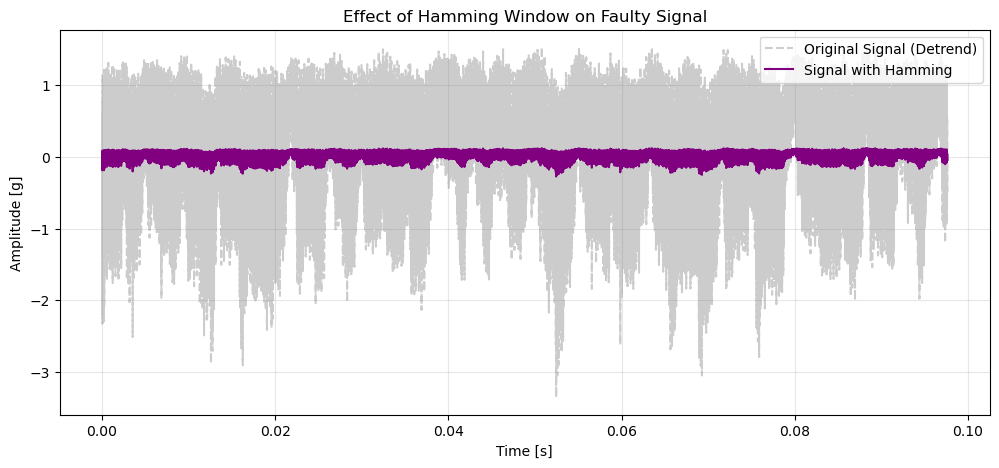

In [7]:
# --- 3. PREPROCESSING (DETREND + HAMMING) ---
def preprocess_signal(sig):
    sig_detrend = signal.detrend(sig)
    window = hamming(len(sig_detrend))
    return sig_detrend * window, sig_detrend

sig_n_clean, _ = preprocess_signal(sig_n_raw)
sig_f_clean, sig_f_detrend = preprocess_signal(sig_f_raw)

fig, ax = setup_graph(title='Effect of Hamming Window on Faulty Signal', 
                      x_label='Time [s]', y_label='Amplitude [g]')

ax.plot(time[:zoom], sig_f_detrend[:zoom], label='Original Signal (Detrend)', color='gray', alpha=0.4, linestyle='--')
ax.plot(time[:zoom], sig_f_clean[:zoom], label='Signal with Hamming', color='purple', linewidth=1.5)
ax.legend(loc='upper right')
plt.show()

## 4. Análisis en el Dominio de la Frecuencia (FFT)
Aplicamos la Transformada Rápida de Fourier. Buscamos picos de energía inusuales que coincidan con los armónicos (múltiplos) de la frecuencia fundamental de giro del motor (aprox. 18.84 Hz), síntoma claro de desalineación.

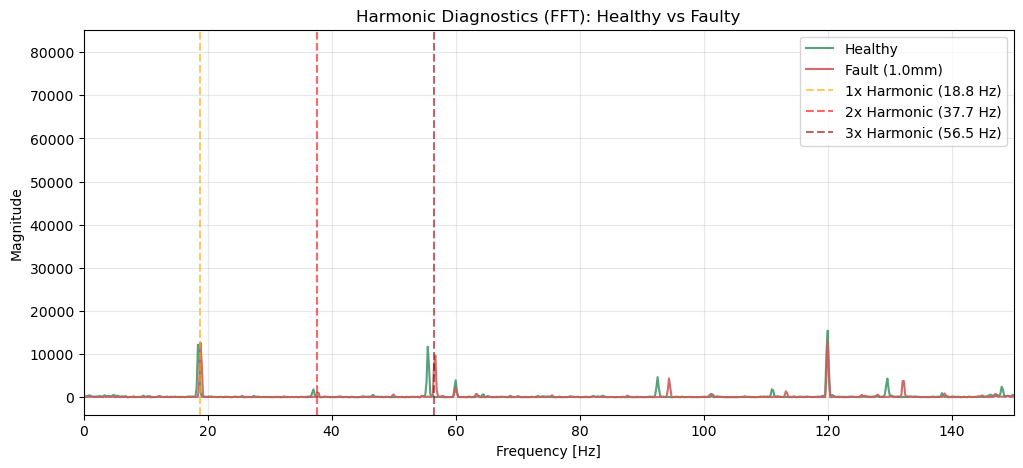

In [8]:
# --- 4. FREQUENCY DOMAIN ANALYSIS (FFT) ---
def calculate_fft(sig, fs=51200):
    n = len(sig)
    yf = fft(sig)
    xf = fftfreq(n, 1/fs)
    return xf[:n//2], np.abs(yf[:n//2])

xf, mag_n = calculate_fft(sig_n_clean)
_, mag_f = calculate_fft(sig_f_clean)

fr = 18.84 # Fundamental rotational frequency

fig, ax = setup_graph(title='Harmonic Diagnostics (FFT): Healthy vs Faulty', 
                      x_label='Frequency [Hz]', y_label='Magnitude')

ax.plot(xf, mag_n, color='seagreen', label='Healthy', alpha=0.8)
ax.plot(xf, mag_f, color='indianred', label='Fault (1.0mm)', alpha=0.9)

harm_colors = ['orange', 'red', 'darkred']
for n in range(1, 4):
    ax.axvline(fr * n, color=harm_colors[n-1], linestyle='--', alpha=0.6, 
               label=f'{n}x Harmonic ({fr*n:.1f} Hz)')

ax.set_xlim(0, 150) # Zoom to see the harmonics
ax.legend()
plt.show()

## 5. Análisis Multicanal (Ejes y Micrófono)
Evaluamos qué eje físico (Axial, Radial o Tangencial) absorbe más energía de impacto (RMS) y contrastamos la huella espectral de la vibración contra la firma acústica recogida por el micrófono.

In [9]:
# --- CORRECCIÓN PARA EL ANÁLISIS DEL MICRÓFONO ---
sig_mic_raw = df_f['microphone'].values
sig_mic_clean, _ = preprocess_signal(sig_mic_raw)
xf_mic, mag_mic = calculate_fft(sig_mic_clean) # Ahora xf_mic y mag_mic están definidos

# Ya puedes ejecutar el plot original:
axs[1].plot(xf, mag_f, color='indianred', label='Vibration (Axial)', alpha=0.8)
axs[1].plot(xf_mic, mag_mic, color='goldenrod', label='Acoustics (Microphone)', alpha=0.7)

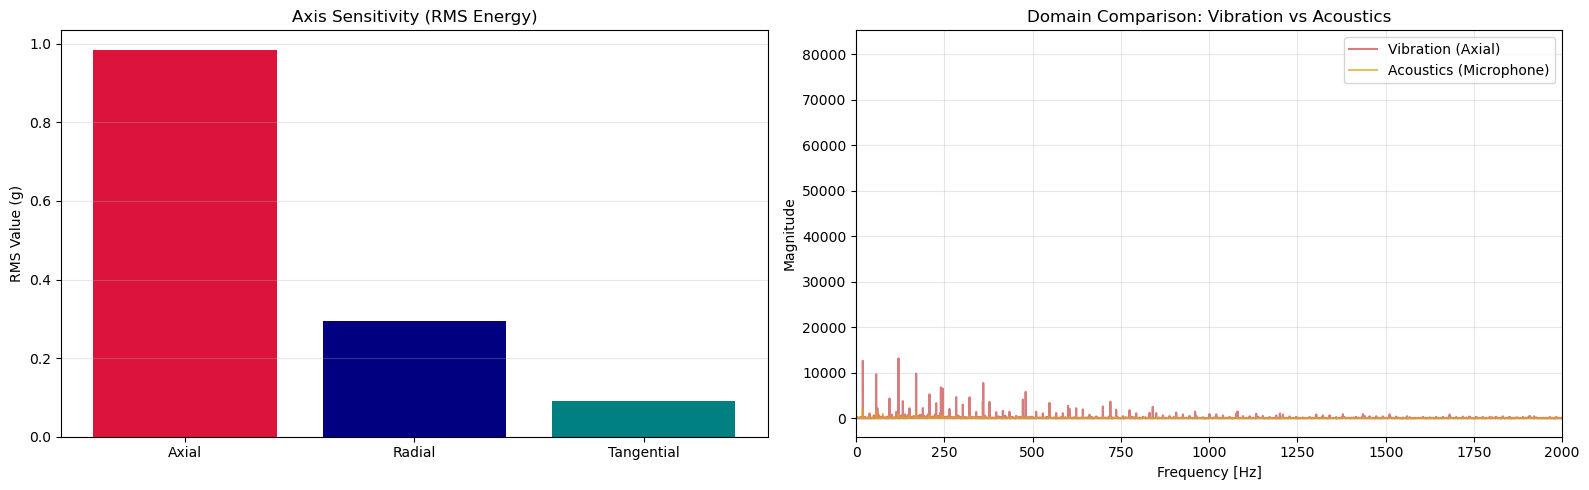

In [10]:
# --- 5. MULTICHANNEL ANALYSIS (AXES AND MICROPHONE) ---
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# 5.1. Comparativa de Ejes (Axial vs Radial vs Tangencial)
sensors_of_interest = ['acc_under_axial', 'acc_under_radiale', 'acc_under_tangencial']

sensor_results = [{
    'Sensor': s.replace('acc_under_', '').replace('radiale', 'radial').replace('tangencial', 'tangential').title(), 
    'RMS': np.sqrt(np.mean(df_f[s].values**2))
} for s in sensors_of_interest]

df_sensors = pd.DataFrame(sensor_results).sort_values(by='RMS', ascending=False)

axs[0].bar(df_sensors['Sensor'], df_sensors['RMS'], color=['crimson', 'navy', 'teal'])
axs[0].set_title('Axis Sensitivity (RMS Energy)')
axs[0].set_ylabel('RMS Value (g)')
axs[0].grid(True, axis='y', alpha=0.3)

# 5.2. Comparativa Micrófono vs Acelerómetro
# Procesamos la señal del micrófono para evitar el NameError anterior
sig_mic_raw = df_f['microphone'].values
sig_mic_clean, _ = preprocess_signal(sig_mic_raw)
xf_mic, mag_mic = calculate_fft(sig_mic_clean)

# Graficamos ambas señales en el dominio de la frecuencia
axs[1].plot(xf, mag_f, color='indianred', label='Vibration (Axial)', alpha=0.8)
axs[1].plot(xf_mic, mag_mic, color='goldenrod', label='Acoustics (Microphone)', alpha=0.7)

# Configuramos el título y etiquetas (AQUÍ ESTABA EL ERROR)
axs[1].set_title('Domain Comparison: Vibration vs Acoustics')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel('Magnitude')
axs[1].set_xlim(0, 2000) # Ajustamos el zoom para ver las firmas acústicas
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Espectrograma y Separabilidad Matemática
Finalizamos el EDA comprobando la evolución temporal de las frecuencias (STFT) y extrayendo un resumen estadístico para validar la separabilidad matemática de las clases antes de entrenar la IA.

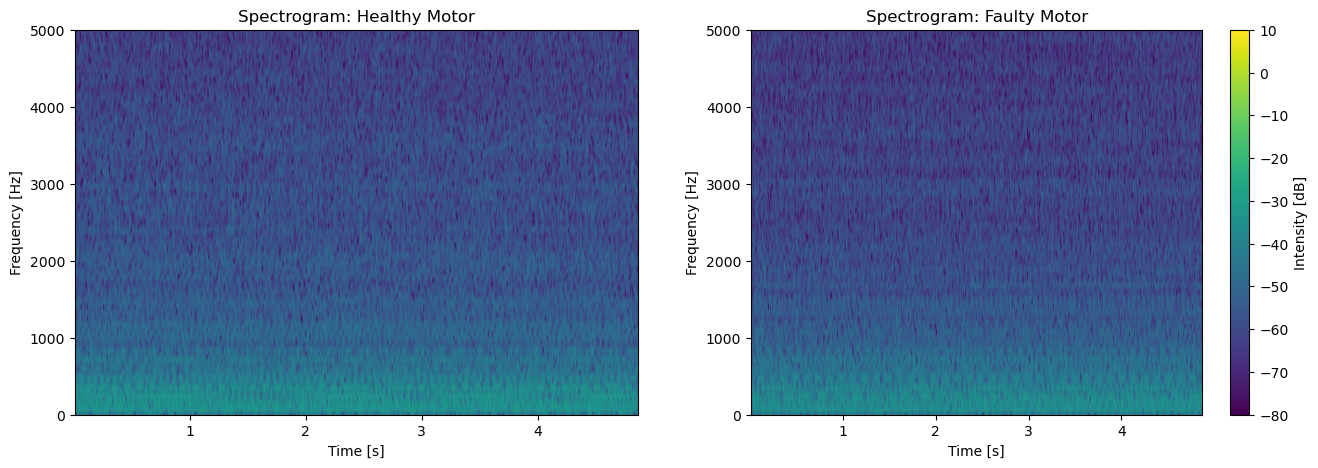

--- 6. SEPARABILITY ANALYSIS ---
The mechanical fault increases the vibration energy (RMS) by -10.72%


,Class,RMS (Energy),Kurtosis (Impacts),Skewness (Asymmetry),Absolute Maximum
0,Healthy (Normal),1.103432,-0.854676,-0.414823,4.1526
1,Fault (1.0mm),0.985098,-0.869129,-0.402566,3.9108


In [11]:
# --- 6. SPECTROGRAM AND SEPARABILITY ---

# IMPORTANTE: Aseguramos que las variables detrend existan capturando el segundo valor de retorno
sig_n_clean, sig_n_detrend = preprocess_signal(sig_n_raw)
sig_f_clean, sig_f_detrend = preprocess_signal(sig_f_raw)

# 6.1 Spectrograms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Healthy Motor Spectrogram (Usamos la señal detrend para evitar distorsiones de borde en el STFT)
f, t, Sxx_n = signal.spectrogram(sig_n_detrend, FS, window='hamming', nperseg=1024, noverlap=512)
ax1.pcolormesh(t, f, 10 * np.log10(Sxx_n + 1e-10), shading='gouraud', cmap='viridis', vmax=10, vmin=-80)
ax1.set_title('Spectrogram: Healthy Motor')
ax1.set_ylim(0, 5000)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Frequency [Hz]')

# Faulty Motor Spectrogram
f, t, Sxx_f = signal.spectrogram(sig_f_detrend, FS, window='hamming', nperseg=1024, noverlap=512)
im = ax2.pcolormesh(t, f, 10 * np.log10(Sxx_f + 1e-10), shading='gouraud', cmap='viridis', vmax=10, vmin=-80)
ax2.set_title('Spectrogram: Faulty Motor')
ax2.set_ylim(0, 5000)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Frequency [Hz]')

fig.colorbar(im, ax=ax2, label='Intensity [dB]')
plt.show()

# 6.2 Mathematical Separability Table
def extract_metrics(df, class_name):
    # Usamos el sensor más sensible identificado en el paso 5 (Axial)
    data = df['acc_under_axial'].values
    return {
        'Class': class_name,
        'RMS (Energy)': np.sqrt(np.mean(data**2)),
        'Kurtosis (Impacts)': kurtosis(data),
        'Skewness (Asymmetry)': skew(data),
        'Absolute Maximum': np.max(np.abs(data))
    }

summary = pd.DataFrame([
    extract_metrics(df_n, "Healthy (Normal)"), 
    extract_metrics(df_f, "Fault (1.0mm)")
])

# Cálculo del incremento de severidad
diff_rms = ((summary.loc[1, 'RMS (Energy)'] - summary.loc[0, 'RMS (Energy)']) / summary.loc[0, 'RMS (Energy)']) * 100

print(f"--- 6. SEPARABILITY ANALYSIS ---")
print(f"The mechanical fault increases the vibration energy (RMS) by {diff_rms:.2f}%")
display(summary)